# 8. BERT Regressor

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cleaned_data = pd.read_pickle("/content/drive/MyDrive/MED-enem/cleaned_data_vectors.pkl").dropna()
cleaned_data.head()

,numero_questao,enunciado,alternativas,nu_param_B,gabarito,ano,enunciado_limpo,alternativas_limpo,vetor_enunciado,vetor_media
0,91,Para realizar o desentupimento de tubulações d...,A: Al; B: Co; C: Cu(OH)2; D: Fe(OH)2; E: Pb,1.13773,A,2019,adicionada aumentando aumentar básico calor co...,A: al; B: co; C: cu oh; D: fe oh; E: pb,"[[-0.192243, -0.234884, -0.190927, -0.201125, ...","[0.026007884853454524, -0.027820302325105944, ..."
1,92,As redes de alta tensão para transmissão de en...,A: Fazer o aterramento dos arames da cerca.; B...,1.45214,A,2019,alta animais aproximarem arame campo cerca cer...,A: arames aterramento cerca fazer; B: acrescen...,"[[-0.078058, -0.390552, -0.379023, 0.086376, 0...","[-0.040842513768718794, 0.016304127806320023, ..."
2,93,A esquistossomose (barriga-dʼágua) caracteriza...,A: impedir a penetração do parasita pela pele....,0.58402,E,2019,anticorpos após barriga baseia baço biomphalar...,A: impedir parasita pele penetração; B: caramu...,"[[0.202009, -0.377567, -0.509075, -0.0262, -0....","[0.025191860097836246, -0.05666966698736998, 0..."
3,94,"Em 1962, um jingle (vinheta musical) criado po...",A: Aquecer a casa e os corpos.; B: Evitar a en...,0.41535,C,2019,abriria animado apesar aquecer associar batia ...,A: aquecer casa corpos; B: casa corpos entrada...,"[[-0.203611, 0.159881, 0.093636, -0.080348, -0...","[-0.006095098719621698, 0.023178725284250343, ..."
4,95,Glicólise é um processo que ocorre nas células...,A: libera 112 kJ por mol de glicose.; B: liber...,2.21432,A,2019,alguns anaeróbico casos combustão completament...,A: glicose kj libera mol; B: glicose kj libera...,"[[-0.000374, -0.127046, -0.401209, -0.020222, ...","[-0.0031903900146461658, 0.002256707901634821,..."


In [ ]:
!pip install torcheval

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 13.8 MB/s eta 0:00:00


In [ ]:
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
from transformers.optimization import get_linear_schedule_with_warmup
from torch.nn.utils.clip_grad import clip_grad_norm_
from torcheval.metrics.functional import r2_score

## 8.1. Treinamento

In [ ]:
full_data = cleaned_data[['enunciado', 'nu_param_B']].dropna()
full_data.head(3)

,enunciado,nu_param_B
0,Para realizar o desentupimento de tubulações d...,1.13773
1,As redes de alta tensão para transmissão de en...,1.45214
2,A esquistossomose (barriga-dʼágua) caracteriza...,0.58402


In [ ]:
#tokenizando os textos de treino e teste

tokenizer = AutoTokenizer.from_pretrained('neuralmind/bert-base-portuguese-cased', do_lower_case=False)

encoded_corpus = tokenizer(text=full_data.enunciado.tolist(),
                            add_special_tokens=True,
                            padding='max_length',
                            truncation='longest_first',
                            max_length=512,
                            return_attention_mask=True)
input_ids = encoded_corpus['input_ids']
attention_mask = encoded_corpus['attention_mask']
labels = full_data.nu_param_B.to_numpy()

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
#20% dos dados para validação
train_and_test_inputs, val_inputs, train_and_test_labels, val_labels = train_test_split(input_ids, labels, test_size = 0.2, random_state=42)
train_and_test_masks, val_masks, _, _ = train_test_split(attention_mask, labels, test_size=0.2, random_state=42)

In [ ]:
#separando 10% dos dados para teste durante o processo de treinamento do modelo

train_inputs, test_inputs, train_labels, test_labels = train_test_split(train_and_test_inputs, train_and_test_labels, test_size=0.1, random_state=42)
train_masks, test_masks, _, _ = train_test_split(train_and_test_masks, train_and_test_labels, test_size=0.1, random_state=42)

In [ ]:
#convertendo os dados em dataloader (aceito pelo pytorch)

batch_size = 8

def create_dataloaders(inputs, masks, labels, batch_size):
    input_tensor = torch.tensor(inputs)
    mask_tensor = torch.tensor(masks)
    labels_tensor = torch.tensor(labels)

    dataset = TensorDataset(input_tensor, mask_tensor, labels_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return dataloader

train_dataloader = create_dataloaders(train_inputs, train_masks, train_labels, batch_size)
test_dataloader = create_dataloaders(test_inputs, test_masks, test_labels, batch_size)
val_dataloader = create_dataloaders(val_inputs, val_masks, val_labels, batch_size)

In [ ]:
#definindo a classe do regressor (bert + camada de regressão)

class BertimbauRegressor(nn.Module):

    def __init__(self, drop_rate=0.2, freeze_bertimbau=False):

        super(BertimbauRegressor, self).__init__()
        D_in, D_out = 768, 1

        self.bertimbau = AutoModel.from_pretrained('neuralmind/bert-base-portuguese-cased')
        self.regressor = nn.Sequential(
            nn.Dropout(drop_rate),
            nn.Linear(D_in, D_out))
        self.double()
    def forward(self, input_ids, attention_masks):

        outputs = self.bertimbau(input_ids, attention_masks)
        class_label_output = outputs[1]
        outputs = self.regressor(class_label_output)
        return outputs
model = BertimbauRegressor(drop_rate=0.2)

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU.")
else:
    print("No GPU available, using the CPU instead.")
    device = torch.device("cpu")
model.to(device)

Using GPU.


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

BertimbauRegressor(
  (bertimbau): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(29794, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, e

In [ ]:
#definindo o otimizador e a loss
optimizer = torch.optim.AdamW(model.parameters(),lr=5e-5,eps=1e-8)
loss_function = nn.MSELoss()

In [ ]:
epochs = 10
total_steps = len(train_dataloader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer,
                 num_warmup_steps=0, num_training_steps=total_steps)

In [ ]:
def train(model, optimizer, scheduler, loss_function, epochs,
          train_dataloader, test_dataloader, device, clip_value=2):

  #métricas de treino total (valor por época)
  loss_list = []
  rmse_list = []
  epoch_list = [] ########

  #métricas de teste total (valor por época)
  test_loss_list = []
  test_rmse_list = []

  for epoch in range(epochs):

    #métricas de treino numa época (valor por batch)
    batch_loss_list = []
    batch_rmse_list = []

    print("\n-----")
    print("EPOCH:",epoch)
    best_loss = 1e10

    model.train()
    for step, batch in enumerate(train_dataloader):
      batch_inputs, batch_masks, batch_labels = tuple(b.to(device) for b in batch)
      model.zero_grad()
      outputs = model(batch_inputs, batch_masks) #implement token ids later

      loss = loss_function(outputs.squeeze(), batch_labels.squeeze())
      rmse = torch.sqrt(loss)

      loss.backward()
      clip_grad_norm_(model.parameters(), clip_value)
      optimizer.step()
      scheduler.step()

      print("   BATCH:",step, '   LOSS:', loss.cpu().detach().numpy(), '   RMSE:', rmse.cpu().detach().numpy())

      batch_loss_list.append(loss)
      batch_rmse_list.append(rmse)
      epoch_list.append(epoch) ########

    #inicia variáveis de test loss e rmse
    test_loss = 0
    test_rmse = 0

    #para cada item do conjunto de teste, calcula mse e rmse daquela época
    model.eval()
    with torch.no_grad():
      for i, test_data in enumerate(test_dataloader):
        test_inputs, test_masks, test_labels = tuple(b.to(device) for b in test_data)
        test_outputs = model(test_inputs, test_masks)
        test_loss += loss_function(test_outputs.squeeze(), test_labels.squeeze())
        test_rmse += torch.sqrt(test_loss)

    #calcula as médias das métricas de treino
    media_loss_treino = (sum(batch_loss_list))/(len(batch_loss_list))
    media_rmse_treino = (sum(batch_rmse_list))/(len(batch_rmse_list))
    loss_list.append((sum(batch_loss_list))/(len(batch_loss_list)))
    rmse_list.append((sum(batch_rmse_list))/(len(batch_rmse_list)))

    #calcula as médias das métricas de teste
    media_loss_teste = test_loss/(i+1)
    media_rmse_teste = test_rmse/(i+1)
    test_loss_list.append(media_loss_teste)
    test_rmse_list.append(media_rmse_teste)

    if media_loss_treino < best_loss:
      best_loss = media_loss_treino
      torch.save(model.state_dict(), '/content/drive/MyDrive/BERT_data/model_v3.pht')


    print('MSE  train:', media_loss_treino.cpu().detach().numpy(), '  test:', media_loss_teste.cpu().detach().numpy())
    print('RMSE  train:', media_rmse_treino.cpu().detach().numpy(), '  test:', media_rmse_teste.cpu().detach().numpy())


  return model, loss_list, rmse_list, test_loss_list, test_rmse_list, best_loss

In [ ]:
model, loss_list, rmse_list, test_loss_list, test_rmse_list, best_loss = train(model, optimizer, scheduler, loss_function, epochs,
                                                                    train_dataloader, test_dataloader, device, clip_value=2)


-----
EPOCH: 0
   BATCH: 0    LOSS: 5.311172891681973    RMSE: 2.3045982061266064
   BATCH: 1    LOSS: 1.8136122683445284    RMSE: 1.3467042245216758
   BATCH: 2    LOSS: 1.011859483696185    RMSE: 1.0059122644128486
   BATCH: 3    LOSS: 1.0387451735747624    RMSE: 1.0191884877561963
   BATCH: 4    LOSS: 0.4966251756332338    RMSE: 0.7047163795692801
   BATCH: 5    LOSS: 0.3885159424906415    RMSE: 0.6233104703842552
   BATCH: 6    LOSS: 0.6486756167128811    RMSE: 0.8054040083789509
   BATCH: 7    LOSS: 0.6958103818139973    RMSE: 0.8341524931413904
   BATCH: 8    LOSS: 0.6288671441290132    RMSE: 0.7930114400997083
   BATCH: 9    LOSS: 1.3239951234393876    RMSE: 1.150649870047091
   BATCH: 10    LOSS: 1.284205989930592    RMSE: 1.133228127929497
   BATCH: 11    LOSS: 0.978753226030473    RMSE: 0.9893195773007188
   BATCH: 12    LOSS: 7.682787354967863    RMSE: 2.771784146532313
   BATCH: 13    LOSS: 1.0238166946313485    RMSE: 1.0118382749389097
   BATCH: 14    LOSS: 0.667342731137

In [ ]:
print('Melhor RMSE treino:', min(rmse_list).cpu().detach().numpy())

Melhor RMSE treino: 0.23617610689463778


In [ ]:
print('Melhor RMSE teste:', min(test_rmse_list).cpu().detach().numpy())

Melhor RMSE teste: 1.4179706871225115


In [ ]:
loss_hist_complete = []
rmse_list_complete = []
rmse_list_complete = []
test_loss_list_complete = []
test_rmse_list_complete = []

for value in loss_list:
  loss_hist_complete.append(float(value.cpu().detach().numpy()))

for value in rmse_list:
  rmse_list_complete.append(float(value.cpu().detach().numpy()))

for value in test_loss_list:
  test_loss_list_complete.append(float(value.cpu().detach().numpy()))

for value in test_rmse_list:
  test_rmse_list_complete.append(float(value.cpu().detach().numpy()))

In [ ]:
dict_results = {'loss_list': loss_hist_complete, 'rmse_list': rmse_list_complete, 'test_loss_list': test_loss_list_complete, 'test_rmse_list': test_rmse_list_complete}
df_results = pd.DataFrame(dict_results)

df_results.head(3)

,loss_list,rmse_list,test_loss_list,test_rmse_list
0,0.975425,0.905518,0.759942,1.417971
1,0.704151,0.773003,0.704743,1.484833
2,0.493849,0.632990,0.947689,1.953048


In [ ]:
df_results.to_pickle('/content/drive/MyDrive/MED-enem/df_results.pkl')

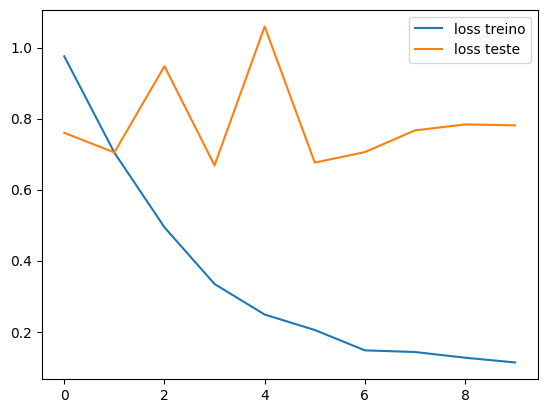

In [ ]:
plt.plot(loss_hist_complete, label='loss treino')
plt.plot(test_loss_list_complete, label='loss teste')
plt.legend()
plt.show()